# Visão Computacional em Ressonância Magnética Cerebral para Apoio à Triagem de Tumores

## Tech Challenge - Fase 1 | Parte Extra

Este notebook complementa a etapa principal do projeto, anteriormente dedicada a dados tabulares, com uma abordagem de Visão Computacional aplicada a imagens médicas. O objetivo é construir um fluxo experimental para classificação de imagens de ressonância magnética cerebral, utilizando o dataset público **Brain Cancer MRI Dataset**, disponível no Kaggle.

A proposta consiste em baixar o dataset diretamente com a biblioteca `kagglehub`, inspecionar sua estrutura real, preparar as imagens, treinar uma CNN simples, treinar um segundo modelo com Transfer Learning, avaliar os resultados e aplicar Grad-CAM para visualizar regiões que influenciaram a decisão dos modelos.

Em exames médicos por imagem, é importante diferenciar três tarefas:

- **Classificação:** atribui uma classe à imagem inteira, por exemplo, presença ou ausência de tumor.
- **Detecção:** identifica regiões da imagem por meio de caixas delimitadoras, conhecidas como bounding boxes.
- **Segmentação:** delimita pixel a pixel a região de interesse, como a área tumoral.

Este notebook prioriza classificação e interpretação visual com Grad-CAM. Caso o dataset não possua anotações supervisionadas de bounding boxes ou máscaras, não será feita detecção ou segmentação real com YOLO. Grad-CAM destaca regiões relevantes para o modelo, mas não equivale a uma segmentação clínica validada.

Os resultados deste projeto têm finalidade acadêmica e exploratória. O modelo pode apoiar uma triagem inicial ou análise preliminar, mas não substitui avaliação de radiologistas, neurologistas, oncologistas ou outros profissionais de saúde. A decisão clínica final deve sempre permanecer com especialistas.

## 1. Configuração do Ambiente

As dependências abaixo foram organizadas para execução no Google Colab. A instalação inclui bibliotecas de manipulação de dados, visualização, processamento de imagens, TensorFlow/Keras para classificação e Ultralytics YOLO para avaliação condicional da possibilidade de detecção/segmentação.

In [5]:
# Execute esta célula no Google Colab se as bibliotecas ainda não estiverem disponíveis.
# A instalação pode levar alguns minutos.

!pip install -q kagglehub opencv-python seaborn scikit-learn tqdm ultralytics

### Importação de bibliotecas e reprodutibilidade

As seeds são configuradas para favorecer reprodutibilidade. Pequenas variações ainda podem ocorrer em GPU, versões de bibliotecas ou operações não determinísticas.

In [6]:
import os
import random
import shutil
import subprocess
import sys
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in {"notebooks", "extra"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_DIR = DATA_RAW_DIR / "brain_cancer_mri"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
YOLO_MODELS_DIR = MODELS_DIR / "yolo"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for directory in [DATA_RAW_DIR, DATASET_DIR, PROCESSED_DIR, MODELS_DIR, YOLO_MODELS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", PROJECT_ROOT.resolve())
print("Pasta do dataset:", DATASET_DIR.resolve())

Raiz do projeto: /content
Pasta do dataset: /content/data/raw/brain_cancer_mri


## 2. Download do Dataset pelo KaggleHub

O dataset será baixado diretamente do Kaggle com a biblioteca `kagglehub`, usando o identificador `orvile/brain-cancer-mri-dataset`.

Essa abordagem simplifica a execução no Google Colab, pois o `kagglehub.dataset_download` gerencia o download e retorna o caminho local onde os arquivos foram disponibilizados. Em alguns ambientes, pode ser necessário estar autenticado no Kaggle.

In [8]:
import kagglehub

# Download latest version
kagglehub_path = Path(kagglehub.dataset_download("orvile/brain-cancer-mri-dataset"))

print("Path to dataset files:", kagglehub_path)

# Mantém uma cópia organizada dentro da estrutura do projeto.
if DATASET_DIR.exists() and any(DATASET_DIR.iterdir()):
    print("Dataset já organizado em:", DATASET_DIR)
else:
    print("Copiando dataset para a estrutura do projeto...")
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    if kagglehub_path.is_file() and kagglehub_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(kagglehub_path, "r") as zip_ref:
            zip_ref.extractall(DATASET_DIR)
    else:
        for item in kagglehub_path.iterdir():
            destination = DATASET_DIR / item.name
            if item.is_dir():
                shutil.copytree(item, destination, dirs_exist_ok=True)
            else:
                shutil.copy2(item, destination)

print("Arquivos disponíveis em data/raw/brain_cancer_mri:")
for path in sorted(DATASET_DIR.rglob("*"))[:40]:
    print(path.relative_to(DATASET_DIR))

Using Colab cache for faster access to the 'brain-cancer-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-cancer-mri-dataset
Copiando dataset para a estrutura do projeto...
Arquivos disponíveis em data/raw/brain_cancer_mri:
Brain_Cancer raw MRI data
Brain_Cancer raw MRI data/Brain_Cancer
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0001.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0002.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0003.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0004.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0005.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0006.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0007.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_0008.jpg
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma

## 3. Inspeção Automática da Estrutura do Dataset

Antes de assumir classes ou formatos, o notebook verifica diretórios, arquivos de imagem, extensões e possíveis anotações. Essa etapa evita conclusões incorretas sobre classificação, detecção ou segmentação.

In [9]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
LABEL_EXTENSIONS = {".txt", ".xml", ".json", ".yaml", ".yml", ".csv"}

all_files = [path for path in DATASET_DIR.rglob("*") if path.is_file()]
image_files = [path for path in all_files if path.suffix.lower() in IMAGE_EXTENSIONS]
label_like_files = [path for path in all_files if path.suffix.lower() in LABEL_EXTENSIONS]

print(f"Total de arquivos: {len(all_files)}")
print(f"Total de imagens: {len(image_files)}")
print(f"Possíveis arquivos de labels/metadados: {len(label_like_files)}")

extension_counts = Counter(path.suffix.lower() for path in all_files)
display(pd.DataFrame(extension_counts.items(), columns=["extensao", "quantidade"]).sort_values("quantidade", ascending=False))

print("\nDiretórios encontrados:")
for directory in sorted([p for p in DATASET_DIR.rglob("*") if p.is_dir()])[:80]:
    print(directory.relative_to(DATASET_DIR))

Total de arquivos: 6057
Total de imagens: 6056
Possíveis arquivos de labels/metadados: 1


,extensao,quantidade
1,.jpg,6056
0,.csv,1



Diretórios encontrados:
Brain_Cancer raw MRI data
Brain_Cancer raw MRI data/Brain_Cancer
Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma
Brain_Cancer raw MRI data/Brain_Cancer/brain_menin
Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor


In [10]:
def infer_class_from_path(image_path, root_dir):
    relative_parts = image_path.relative_to(root_dir).parts
    if len(relative_parts) <= 1:
        return "classe_indefinida"
    return relative_parts[-2]

records = []
for image_path in image_files:
    records.append({
        "path": image_path,
        "relative_path": str(image_path.relative_to(DATASET_DIR)),
        "class_name": infer_class_from_path(image_path, DATASET_DIR),
        "extension": image_path.suffix.lower(),
    })

df_images = pd.DataFrame(records)
display(df_images.head())
print("Classes inferidas pelas pastas:")
display(df_images["class_name"].value_counts().to_frame("quantidade"))

,path,relative_path,class_name,extension
0,/content/data/raw/brain_cancer_mri/Brain_Cance...,Brain_Cancer raw MRI data/Brain_Cancer/brain_g...,brain_glioma,.jpg
1,/content/data/raw/brain_cancer_mri/Brain_Cance...,Brain_Cancer raw MRI data/Brain_Cancer/brain_g...,brain_glioma,.jpg
2,/content/data/raw/brain_cancer_mri/Brain_Cance...,Brain_Cancer raw MRI data/Brain_Cancer/brain_g...,brain_glioma,.jpg
3,/content/data/raw/brain_cancer_mri/Brain_Cance...,Brain_Cancer raw MRI data/Brain_Cancer/brain_g...,brain_glioma,.jpg
4,/content/data/raw/brain_cancer_mri/Brain_Cance...,Brain_Cancer raw MRI data/Brain_Cancer/brain_g...,brain_glioma,.jpg


Classes inferidas pelas pastas:


,quantidade
class_name,
brain_tumor,2048
brain_glioma,2004
brain_menin,2004


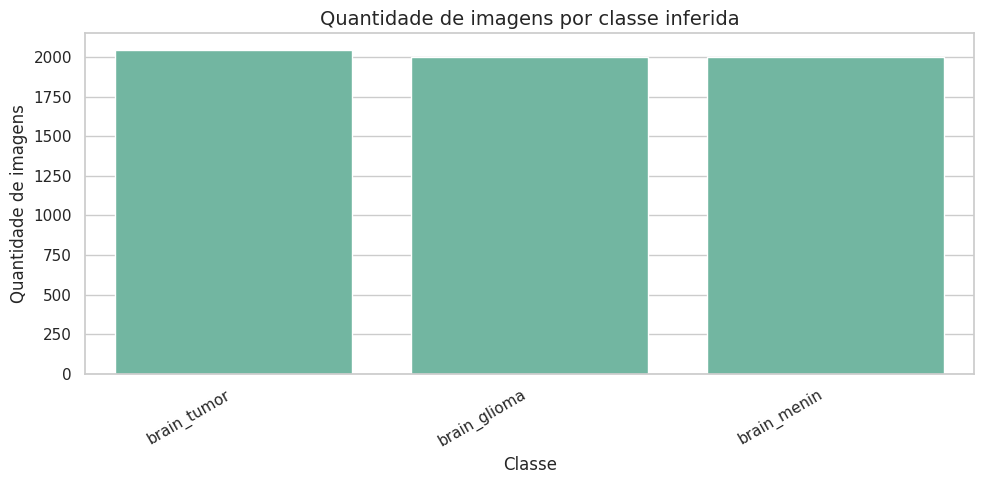

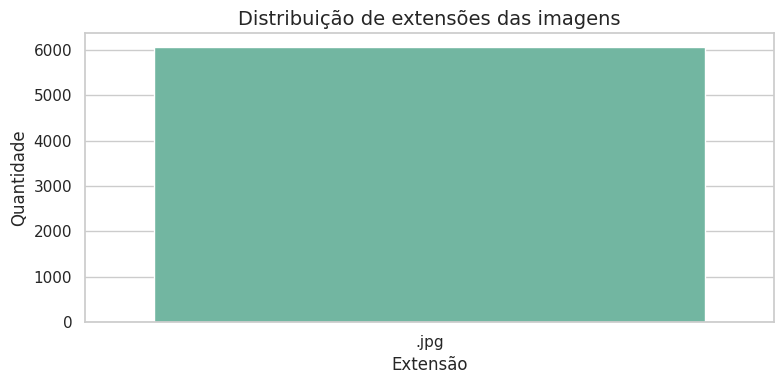

In [11]:
plt.figure(figsize=(10, 5))
class_counts = df_images["class_name"].value_counts().reset_index()
class_counts.columns = ["classe", "quantidade"]
sns.barplot(data=class_counts, x="classe", y="quantidade")
plt.title("Quantidade de imagens por classe inferida")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
extension_df = df_images["extension"].value_counts().reset_index()
extension_df.columns = ["extensao", "quantidade"]
sns.barplot(data=extension_df, x="extensao", y="quantidade")
plt.title("Distribuição de extensões das imagens")
plt.xlabel("Extensão")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Verificação de imagens inválidas, dimensões e canais

Imagens médicas podem ter tamanhos, formatos e canais diferentes. A inspeção abaixo registra dimensões e remove apenas arquivos impossíveis de abrir.

In [12]:
def inspect_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            return {
                "path": path,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "valid": True,
                "error": None,
            }
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        return {
            "path": path,
            "width": np.nan,
            "height": np.nan,
            "mode": None,
            "valid": False,
            "error": str(exc),
        }

inspection = [inspect_image(path) for path in tqdm(image_files, desc="Inspecionando imagens")]
df_inspection = pd.DataFrame(inspection)

df_images = df_images.merge(df_inspection, on="path", how="left")
invalid_images = df_images[~df_images["valid"]]

print(f"Imagens inválidas/corrompidas: {len(invalid_images)}")
if len(invalid_images) > 0:
    display(invalid_images[["relative_path", "error"]].head(20))

df_images_valid = df_images[df_images["valid"]].copy().reset_index(drop=True)
display(df_images_valid[["class_name", "extension", "width", "height", "mode"]].head())

Inspecionando imagens:   0%|          | 0/6056 [00:00<?, ?it/s]

Imagens inválidas/corrompidas: 0


,class_name,extension,width,height,mode
0,brain_glioma,.jpg,512,512,RGB
1,brain_glioma,.jpg,512,512,RGB
2,brain_glioma,.jpg,512,512,RGB
3,brain_glioma,.jpg,512,512,RGB
4,brain_glioma,.jpg,512,512,RGB


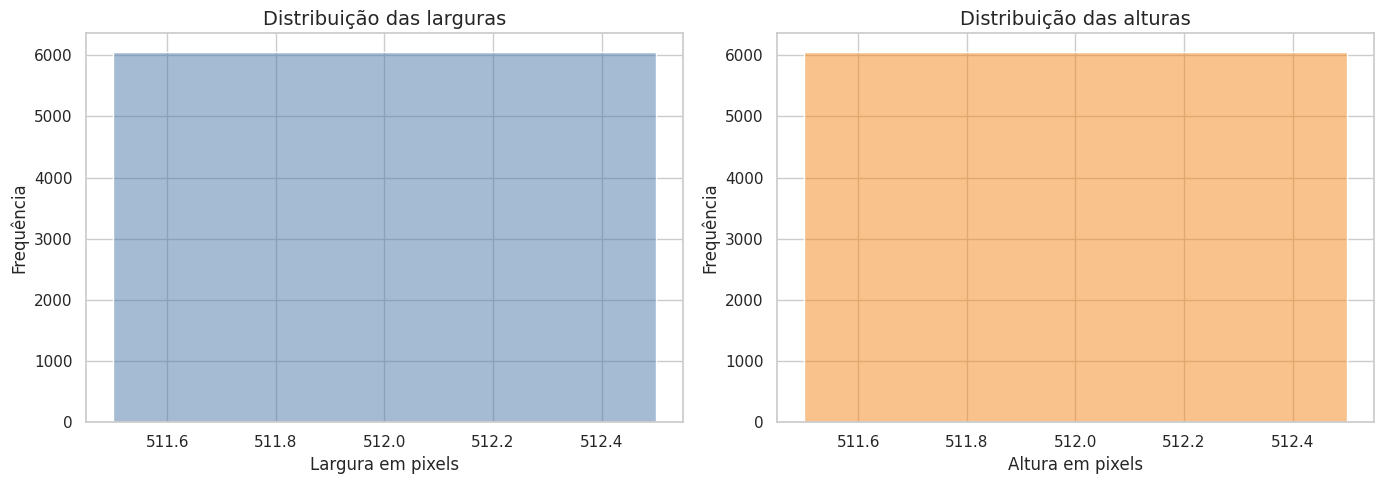

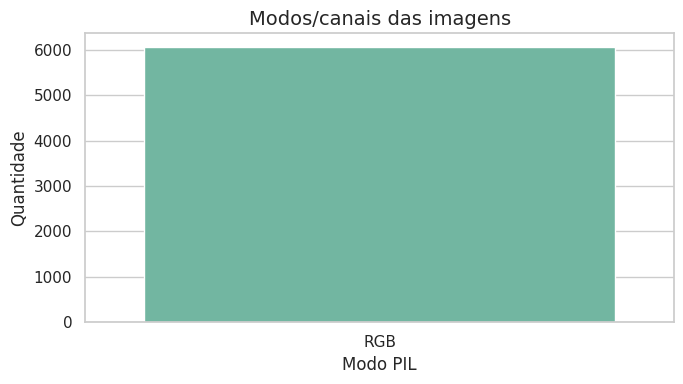

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_images_valid["width"], kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribuição das larguras")
axes[0].set_xlabel("Largura em pixels")
axes[0].set_ylabel("Frequência")

sns.histplot(df_images_valid["height"], kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Distribuição das alturas")
axes[1].set_xlabel("Altura em pixels")
axes[1].set_ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
mode_df = df_images_valid["mode"].value_counts().reset_index()
mode_df.columns = ["modo", "quantidade"]
sns.barplot(data=mode_df, x="modo", y="quantidade")
plt.title("Modos/canais das imagens")
plt.xlabel("Modo PIL")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [14]:
def compute_file_signature(path, block_size=65536):
    import hashlib
    hasher = hashlib.md5()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(block_size), b""):
            hasher.update(block)
    return hasher.hexdigest()

df_images_valid["file_hash"] = [compute_file_signature(path) for path in tqdm(df_images_valid["path"], desc="Calculando hashes")]
duplicate_count = df_images_valid.duplicated("file_hash").sum()
print(f"Possíveis imagens duplicadas por hash: {duplicate_count}")
if duplicate_count > 0:
    display(df_images_valid[df_images_valid.duplicated("file_hash", keep=False)][["relative_path", "class_name", "file_hash"]].head(20))

Calculando hashes:   0%|          | 0/6056 [00:00<?, ?it/s]

Possíveis imagens duplicadas por hash: 44


,relative_path,class_name,file_hash
4025,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,6963b1c32ceae61e5c85a3a0d7443fdc
4031,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,84bbc3d4de558e1cb5183c6547071295
4060,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,84bbc3d4de558e1cb5183c6547071295
4113,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,02dbbdb2e096de5ba9116aee0591dc09
4150,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,98fe04270eb64b4a3e8038c8eb80e672
4171,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,44edb25b78809466ebf06a2c7307df01
4191,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,20c6fd475824d7b26b50aec84737c9eb
4194,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,a74501b93e23a0315dc3e2f47875ad04
4211,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,35a939e7ba4b1e3dd2b70684a7a1b9a3
4218,Brain_Cancer raw MRI data/Brain_Cancer/brain_t...,brain_tumor,20c6fd475824d7b26b50aec84737c9eb


## 4. Análise Exploratória das Imagens

A análise visual e estatística permite avaliar balanceamento das classes, variação de tamanhos, brilho, contraste e possíveis desafios de modelagem. Bases pequenas ou muito homogêneas podem favorecer overfitting, especialmente em redes neurais treinadas do zero.

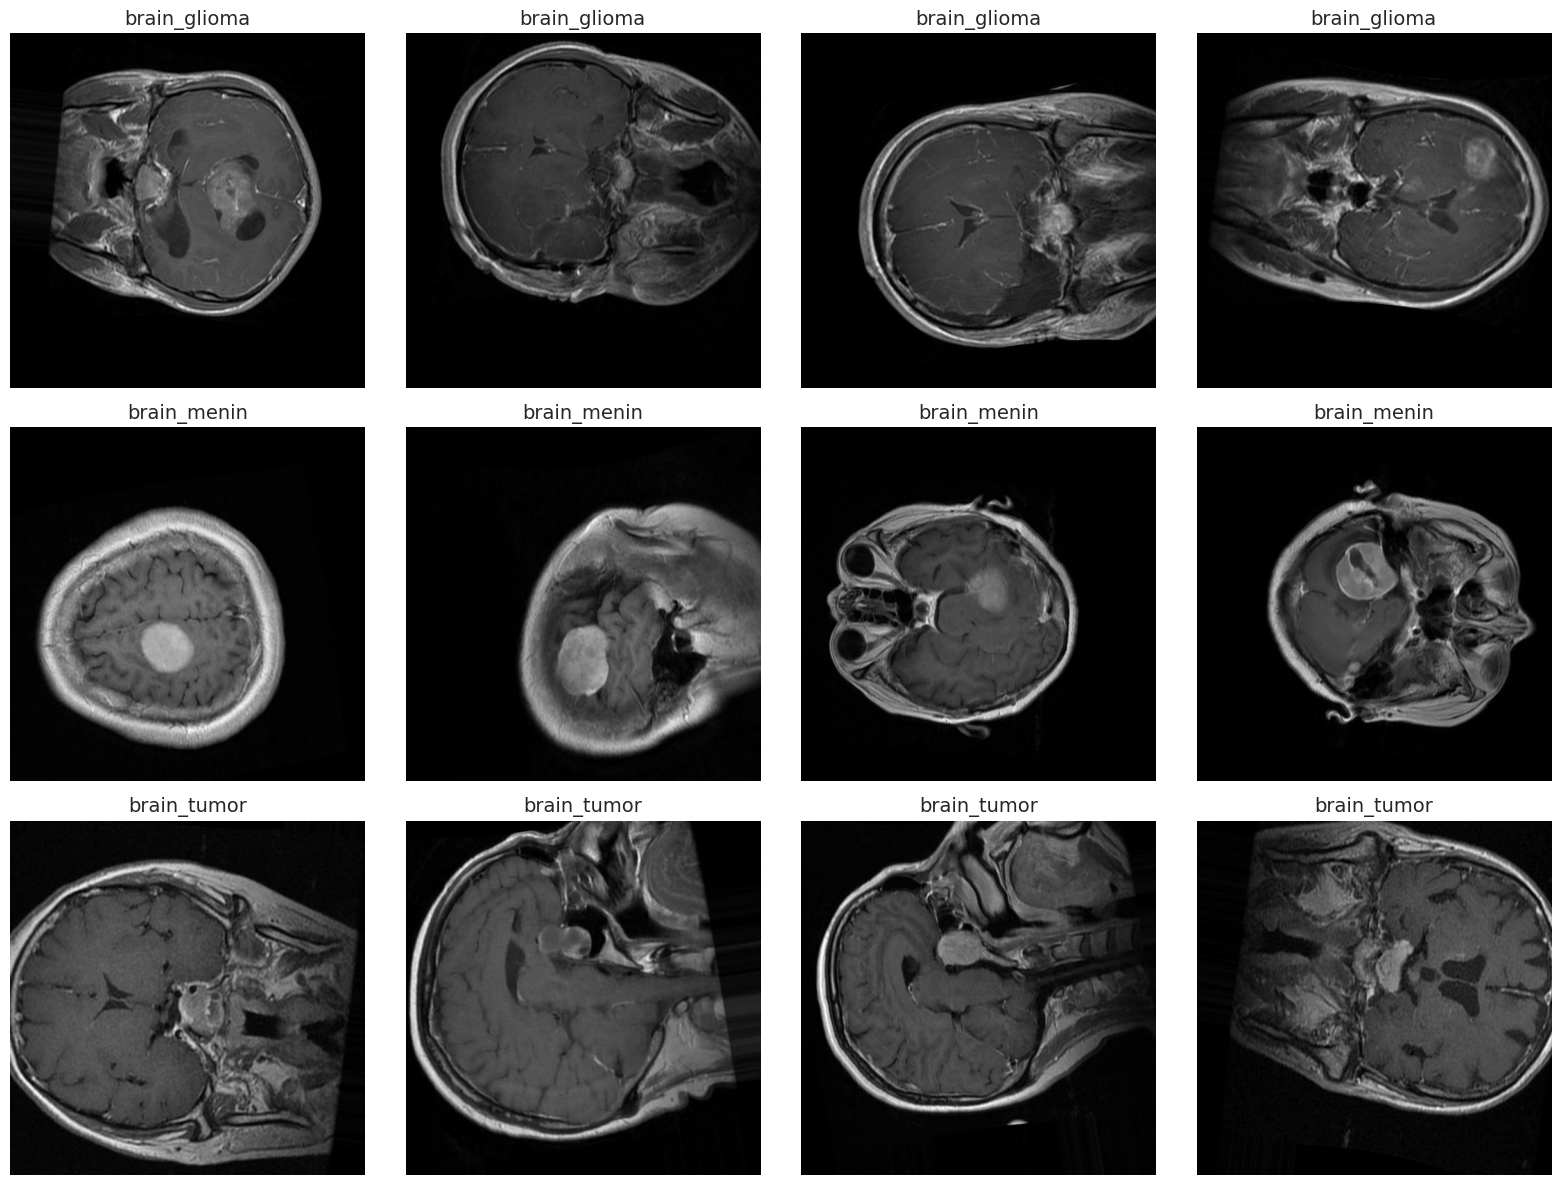

In [15]:
def load_rgb_image(path, target_size=None):
    image = Image.open(path).convert("RGB")
    if target_size is not None:
        image = image.resize(target_size)
    return np.array(image)

def plot_samples_by_class(df, samples_per_class=4):
    classes = sorted(df["class_name"].unique())
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(4 * samples_per_class, 4 * len(classes)))
    if len(classes) == 1:
        axes = np.array([axes])
    for row_idx, class_name in enumerate(classes):
        subset = df[df["class_name"] == class_name].sample(
            min(samples_per_class, len(df[df["class_name"] == class_name])),
            random_state=SEED,
        )
        for col_idx in range(samples_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx < len(subset):
                image = load_rgb_image(subset.iloc[col_idx]["path"])
                ax.imshow(image, cmap="gray")
                ax.set_title(class_name)
    plt.tight_layout()
    plt.show()

plot_samples_by_class(df_images_valid, samples_per_class=4)

Calculando brilho/contraste:   0%|          | 0/6056 [00:00<?, ?it/s]

mean_intensity                                             \
                      count       mean       std        min        25%   
class_name                                                               
brain_glioma         2004.0  29.353834  6.470811  11.653717  24.625236   
brain_menin          2004.0  39.763606  8.058040  18.601921  33.906905   
brain_tumor          2048.0  48.752010  8.532003  21.166321  43.113569   

                                              std_intensity             \
                    50%        75%        max         count       mean   
class_name                                                               
brain_glioma  29.025036  33.618113  54.102142        2004.0  38.118666   
brain_menin   39.312500  45.034372  71.257511        2004.0  46.488610   
brain_tumor   48.643351  54.270068  80.490257        2048.0  43.014361   

                                                                               
                   std        min        25%        50%        75%        max  
class_name                                                                     
brain_glioma  5.566180  20.359149  34.371618  38.153412  41.733952  61.999150  
brain_menin   5.562185  24.379131  42.928056  46.178395  49.751135  71.212386  
brain_tumor   5.337927  23.862159  39.367338  43.001673  46.369334  63.412473

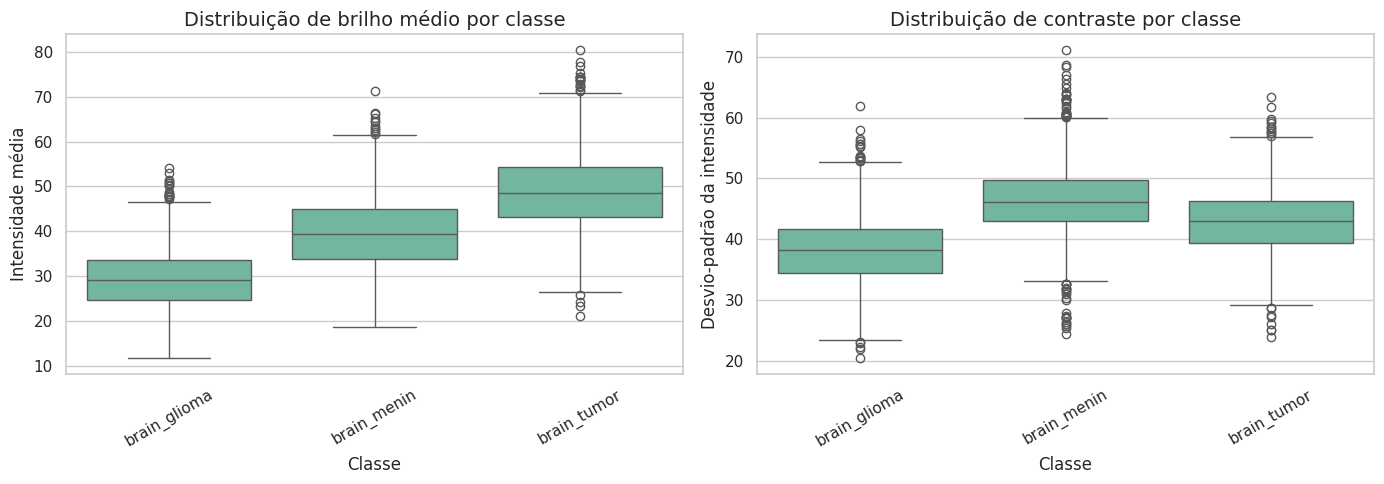

In [17]:
brightness_records = []
for _, row in tqdm(df_images_valid.iterrows(), total=len(df_images_valid), desc="Calculando brilho/contraste"):
    image = cv2.imread(str(row["path"]), cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue
    brightness_records.append({
        "path": row["path"],
        "class_name": row["class_name"],
        "mean_intensity": float(np.mean(image)),
        "std_intensity": float(np.std(image)),
    })

df_intensity = pd.DataFrame(brightness_records)
display(df_intensity.groupby("class_name")[["mean_intensity", "std_intensity"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_intensity, x="class_name", y="mean_intensity", ax=axes[0])
axes[0].set_title("Distribuição de brilho médio por classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Intensidade média")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df_intensity, x="class_name", y="std_intensity", ax=axes[1])
axes[1].set_title("Distribuição de contraste por classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Desvio-padrão da intensidade")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Os gráficos de brilho e contraste ajudam a identificar diferenças globais entre classes e possíveis variações de aquisição. Diferenças muito marcantes podem facilitar a classificação, mas também podem indicar viés de coleta se estiverem associadas a equipamentos, protocolos ou fontes distintas.

## 5. Preparação dos Dados

As imagens serão redimensionadas para `224x224`, normalizadas para o intervalo `[0, 1]` e divididas em treino, validação e teste. A divisão será estratificada quando houver quantidade suficiente de exemplos por classe. Data augmentation será aplicado apenas ao conjunto de treino.

In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

df_model = df_images_valid.copy()
df_model = df_model[df_model["class_name"] != "classe_indefinida"].reset_index(drop=True)

if df_model["class_name"].nunique() < 2:
    raise ValueError("Foram encontradas menos de duas classes. Verifique a estrutura do dataset antes de modelar.")

label_encoder = LabelEncoder()
df_model["label"] = label_encoder.fit_transform(df_model["class_name"])
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

print("Classes utilizadas:", class_names)
print("Número de classes:", num_classes)
display(df_model["class_name"].value_counts().to_frame("quantidade"))

Classes utilizadas: ['brain_glioma', 'brain_menin', 'brain_tumor']
Número de classes: 3


,quantidade
class_name,
brain_tumor,2048
brain_glioma,2004
brain_menin,2004


In [19]:
stratify_labels = df_model["label"] if df_model["label"].value_counts().min() >= 2 else None

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_labels,
)

temp_stratify = temp_df["label"] if temp_df["label"].value_counts().min() >= 2 else None
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_stratify,
)

split_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "quantidade": [len(train_df), len(val_df), len(test_df)],
    "percentual": [len(train_df)/len(df_model), len(val_df)/len(df_model), len(test_df)/len(df_model)],
})
split_summary["percentual"] = (split_summary["percentual"] * 100).round(2)
display(split_summary)

display(pd.crosstab(train_df["class_name"], columns="treino"))
display(pd.crosstab(val_df["class_name"], columns="validacao"))
display(pd.crosstab(test_df["class_name"], columns="teste"))

,conjunto,quantidade,percentual
0,treino,4239,70.00
1,validação,908,14.99
2,teste,909,15.01


col_0,treino
class_name,
brain_glioma,1403
brain_menin,1403
brain_tumor,1433


col_0,validacao
class_name,
brain_glioma,300
brain_menin,301
brain_tumor,307


col_0,teste
class_name,
brain_glioma,301
brain_menin,300
brain_tumor,308


In [20]:
def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(df, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="data_augmentation")

## 6. Modelo 1 - CNN Simples para Classificação

A primeira abordagem utiliza uma CNN construída do zero. Esse modelo serve como baseline para avaliar se a base possui sinal visual suficiente para classificação sem uso de pesos pré-treinados.

In [21]:
def build_simple_cnn(input_shape=(224, 224, 3), num_classes=2):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same", name="last_conv_simple")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid", name="classifier")(x)
        loss = "binary_crossentropy"
        metrics = [
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ]
    else:
        outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)
        loss = "sparse_categorical_crossentropy"
        metrics = ["accuracy"]

    model = keras.Model(inputs, outputs, name="cnn_simples_mri")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=loss, metrics=metrics)
    return model

cnn_model = build_simple_cnn(num_classes=num_classes)
cnn_model.summary()

Model: "cnn_simples_mri"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_simple (Conv2D)       │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,107 (1.49 MB)

 Trainable params: 390,147 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
cnn_checkpoint = MODELS_DIR / "cnn_simples.keras"
cnn_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(cnn_checkpoint, monitor="val_loss", save_best_only=True),
]

EPOCHS_CNN = 30

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7952 - loss: 0.5156 - val_accuracy: 0.3381 - val_loss: 2.9804
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8705 - loss: 0.3564 - val_accuracy: 0.3381 - val_loss: 7.2395
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8927 - loss: 0.3027 - val_accuracy: 0.6090 - val_loss: 4.0001
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9101 - loss: 0.2521 - val_accuracy: 0.4020 - val_loss: 6.0783
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9080 - loss: 0.2482 - val_accuracy: 0.4064 - val_loss: 4.7788
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9120 - loss: 0.2455 - val_accuracy: 0.6795 - val_loss: 0.8265
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9250 - loss: 0.2096 - val_accuracy: 0.6993 - val_loss: 0.8583
Epoch 8/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9255 - loss: 0.2022 - val_acc

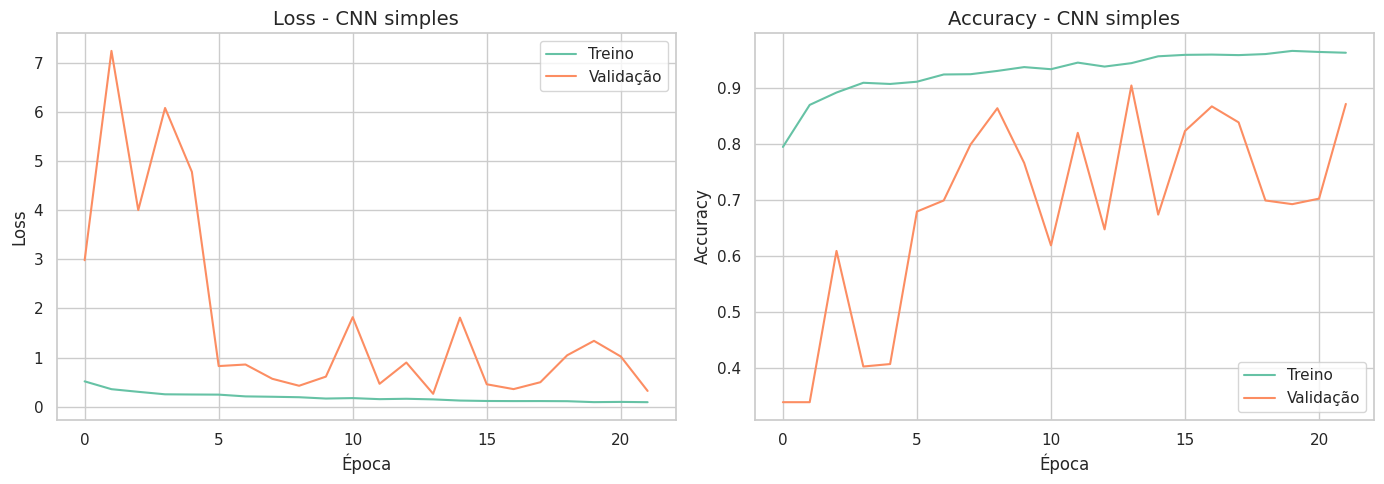

In [23]:
def plot_training_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["loss"], label="Treino")
    axes[0].plot(history_df["val_loss"], label="Validação")
    axes[0].set_title(f"Loss - {title}")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    if "accuracy" in history_df.columns:
        axes[1].plot(history_df["accuracy"], label="Treino")
        axes[1].plot(history_df["val_accuracy"], label="Validação")
        axes[1].set_title(f"Accuracy - {title}")
        axes[1].set_xlabel("Época")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn, "CNN simples")

## 7. Avaliação da CNN Simples

A avaliação no teste será feita após o treinamento, sem usar o conjunto de teste para escolha de hiperparâmetros. Em saúde, recall é uma métrica especialmente sensível, pois falsos negativos podem significar deixar de sinalizar uma imagem potencialmente suspeita.

Resultados - CNN simples


,accuracy,precision,recall,f1,auc
CNN simples,0.90319,0.917361,0.902259,0.901115,0.991586


              precision    recall  f1-score   support

brain_glioma       0.97      0.97      0.97       301
 brain_menin       0.97      0.74      0.84       300
 brain_tumor       0.81      1.00      0.89       308

    accuracy                           0.90       909
   macro avg       0.92      0.90      0.90       909
weighted avg       0.92      0.90      0.90       909



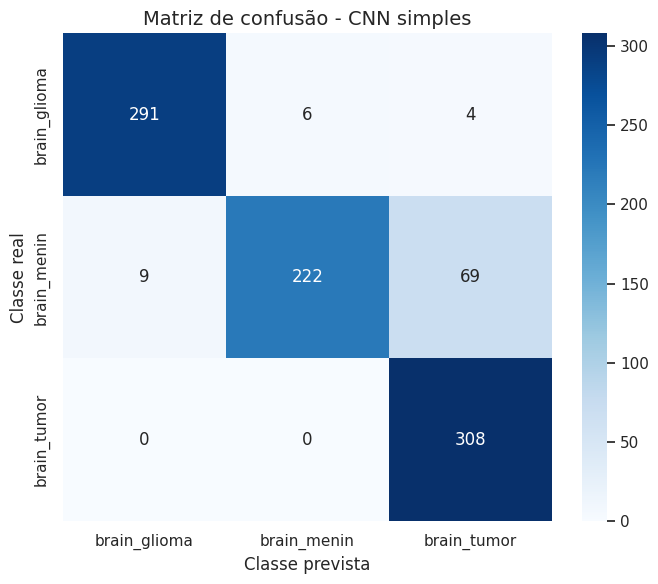

In [24]:
def predict_dataset(model, dataset, num_classes):
    y_true = []
    y_score = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_score.extend(preds.tolist())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    if num_classes == 2:
        y_score = y_score.reshape(-1)
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_pred = np.argmax(y_score, axis=1)

    return y_true, y_pred, y_score

def compute_metrics(y_true, y_pred, y_score, num_classes):
    average = "binary" if num_classes == 2 else "macro"
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }

    try:
        if num_classes == 2:
            metrics["auc"] = roc_auc_score(y_true, y_score)
        else:
            y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
            metrics["auc"] = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
    except ValueError:
        metrics["auc"] = np.nan

    return metrics

def evaluate_classifier(model, dataset, model_name, num_classes):
    y_true, y_pred, y_score = predict_dataset(model, dataset, num_classes)
    metrics = compute_metrics(y_true, y_pred, y_score, num_classes)

    print(f"Resultados - {model_name}")
    display(pd.DataFrame([metrics], index=[model_name]))
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Matriz de confusão - {model_name}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.tight_layout()
    plt.show()

    return metrics, y_true, y_pred, y_score

cnn_test_metrics, cnn_y_true, cnn_y_pred, cnn_y_score = evaluate_classifier(
    cnn_model, test_ds, "CNN simples", num_classes
)

In [27]:
if num_classes == 2:
    fpr, tpr, _ = roc_curve(cnn_y_true, cnn_y_score)
    cnn_auc = roc_auc_score(cnn_y_true, cnn_y_score)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"CNN simples (AUC = {cnn_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
    plt.title("Curva ROC - CNN simples")
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Curva ROC binária não exibida porque o problema possui mais de duas classes.")

Curva ROC binária não exibida porque o problema possui mais de duas classes.


## 8. Modelo 2 - Transfer Learning com Fine-tuning

Transfer Learning aproveita representações visuais aprendidas em grandes bases de imagens. Em datasets médicos pequenos, essa estratégia pode melhorar a generalização em comparação com uma CNN treinada do zero. O treinamento será feito em duas etapas: primeiro com a base convolucional congelada e depois com ajuste fino parcial das últimas camadas.

In [28]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=2):
    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid", name="classifier")(x)
        loss = "binary_crossentropy"
        metrics = [
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ]
    else:
        outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)
        loss = "sparse_categorical_crossentropy"
        metrics = ["accuracy"]

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer_mri")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=loss, metrics=metrics)
    return model, base_model

transfer_model, transfer_base = build_transfer_model(num_classes=num_classes)
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer_mri"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7320 - loss: 0.6239 - val_accuracy: 0.8370 - val_loss: 0.3989
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8686 - loss: 0.3485 - val_accuracy: 0.8756 - val_loss: 0.3295
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8877 - loss: 0.2896 - val_accuracy: 0.8811 - val_loss: 0.3032
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9002 - loss: 0.2658 - val_accuracy: 0.8943 - val_loss: 0.2818
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9012 - loss: 0.2572 - val_accuracy: 0.8700 - val_loss: 0.3495
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9104 - loss: 0.2397 - val_accuracy: 0.8392 - val_loss: 0.4358
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9134 - loss: 0.2341 - val_accuracy: 0.8744 - val_loss: 0.3340
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9151 - loss: 0.2233 - val_acc

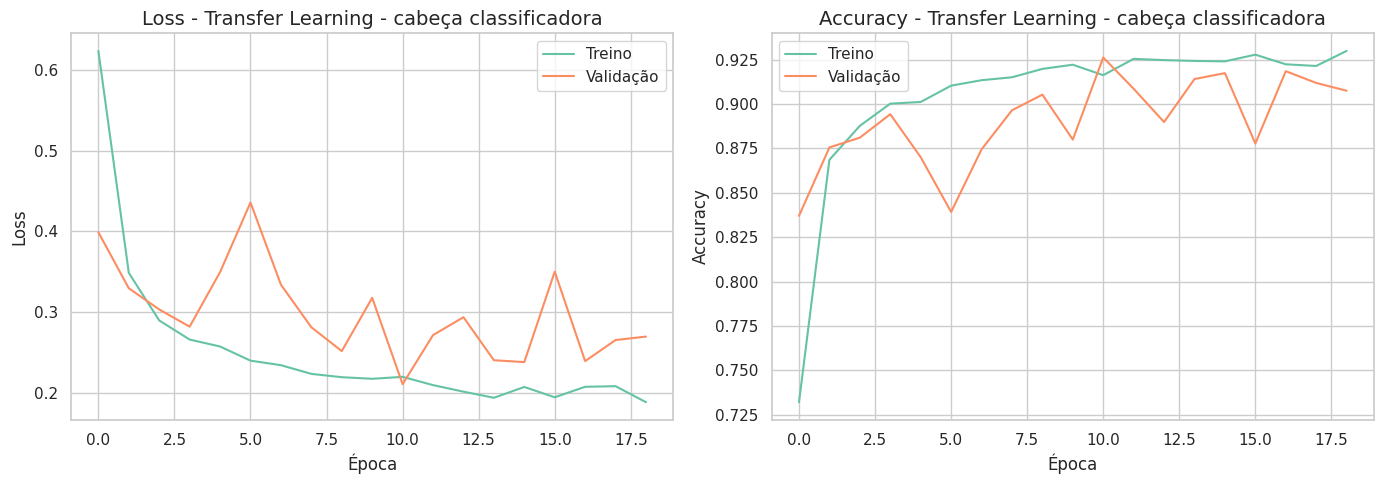

In [29]:
transfer_checkpoint = MODELS_DIR / "transfer_learning_model.keras"
transfer_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(transfer_checkpoint, monitor="val_loss", save_best_only=True),
]

EPOCHS_TRANSFER_HEAD = 20

history_transfer_head = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER_HEAD,
    callbacks=transfer_callbacks,
)

plot_training_history(history_transfer_head, "Transfer Learning - cabeça classificadora")

Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.8613 - loss: 0.3830 - val_accuracy: 0.9229 - val_loss: 0.2049
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9042 - loss: 0.2706 - val_accuracy: 0.9295 - val_loss: 0.1969
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9196 - loss: 0.2205 - val_accuracy: 0.9372 - val_loss: 0.1683
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9292 - loss: 0.1991 - val_accuracy: 0.9427 - val_loss: 0.1627
Epoch 5/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9318 - loss: 0.1775 - val_accuracy: 0.9427 - val_loss: 0.1560
Epoch 6/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9431 - loss: 0.1547 - val_accuracy: 0.9438 - val_loss: 0.1622
Epoch 7/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9488 - loss: 0.1384 - val_accuracy: 0.9504 - val_loss: 0.1540
Epoch 8/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9495 - loss: 0.1327 - val_acc

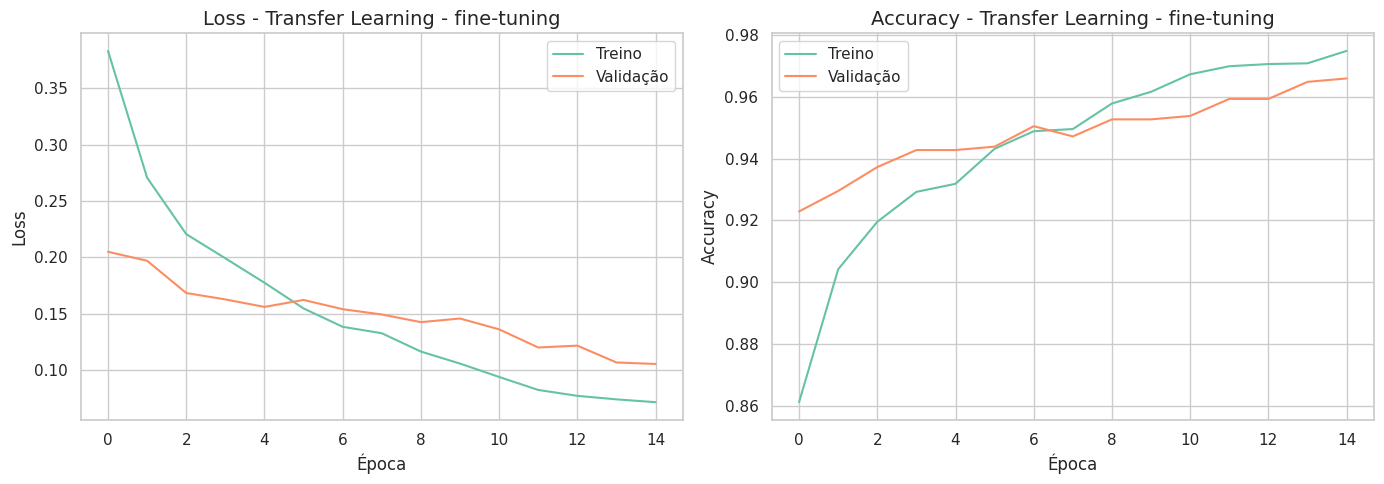

In [30]:
# Fine-tuning parcial das últimas camadas.
transfer_base.trainable = True

fine_tune_at = max(0, len(transfer_base.layers) - 30)
for layer in transfer_base.layers[:fine_tune_at]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy" if num_classes == 2 else "sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ] if num_classes == 2 else ["accuracy"],
)

EPOCHS_FINE_TUNING = 15

history_transfer_ft = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNING,
    callbacks=transfer_callbacks,
)

plot_training_history(history_transfer_ft, "Transfer Learning - fine-tuning")

Resultados - Transfer Learning MobileNetV2


,accuracy,precision,recall,f1,auc
Transfer Learning MobileNetV2,0.960396,0.962231,0.960095,0.960418,0.996149


              precision    recall  f1-score   support

brain_glioma       0.99      0.97      0.98       301
 brain_menin       0.97      0.92      0.95       300
 brain_tumor       0.92      0.99      0.96       308

    accuracy                           0.96       909
   macro avg       0.96      0.96      0.96       909
weighted avg       0.96      0.96      0.96       909



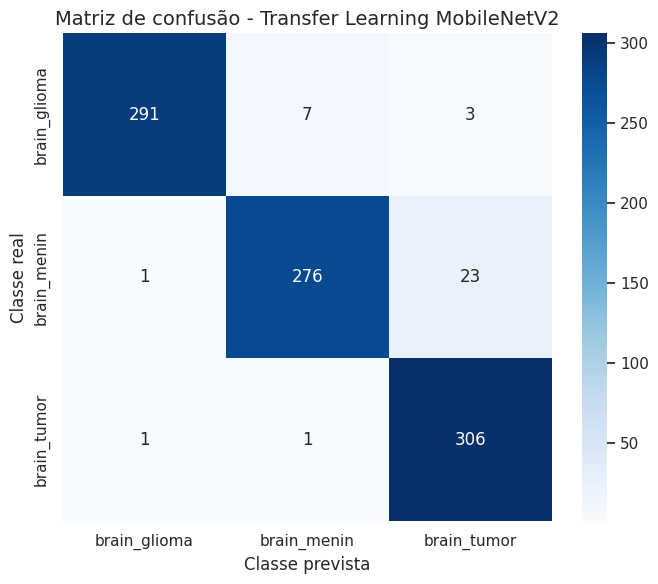

In [31]:
transfer_test_metrics, transfer_y_true, transfer_y_pred, transfer_y_score = evaluate_classifier(
    transfer_model, test_ds, "Transfer Learning MobileNetV2", num_classes
)

if num_classes == 2:
    fpr, tpr, _ = roc_curve(transfer_y_true, transfer_y_score)
    transfer_auc = roc_auc_score(transfer_y_true, transfer_y_score)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"MobileNetV2 (AUC = {transfer_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
    plt.title("Curva ROC - Transfer Learning")
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 9. Comparação entre os Modelos

A seleção do melhor modelo considera recall, F1-score, AUC quando aplicável e coerência entre desempenho observado e risco de overfitting. O conjunto de teste é usado apenas nesta avaliação final, após o treinamento e a validação.

,modelo,accuracy,precision,recall,f1,auc
0,CNN simples,0.903190,0.917361,0.902259,0.901115,0.991586
1,Transfer Learning MobileNetV2,0.960396,0.962231,0.960095,0.960418,0.996149


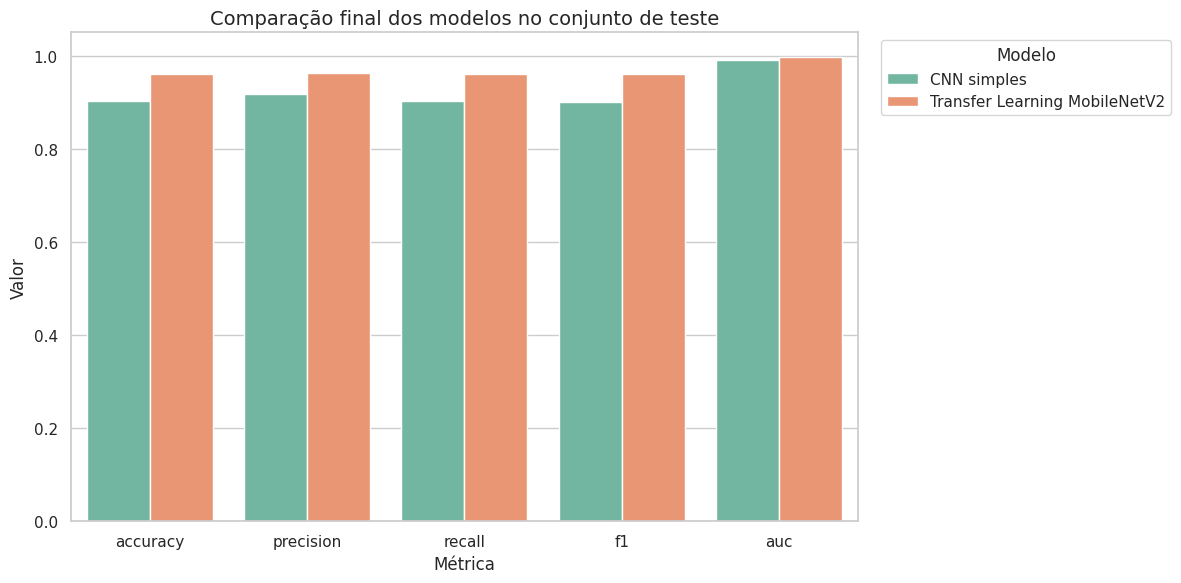

Melhor modelo final: Transfer Learning MobileNetV2


,modelo,accuracy,precision,recall,f1,auc
0,Transfer Learning MobileNetV2,0.960396,0.962231,0.960095,0.960418,0.996149
1,CNN simples,0.903190,0.917361,0.902259,0.901115,0.991586


In [32]:
comparison_df = pd.DataFrame([
    {"modelo": "CNN simples", **cnn_test_metrics},
    {"modelo": "Transfer Learning MobileNetV2", **transfer_test_metrics},
])

display(comparison_df)

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "auc"]
plot_df = comparison_df.melt(id_vars="modelo", value_vars=[c for c in metrics_to_plot if c in comparison_df.columns], var_name="metrica", value_name="valor")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="metrica", y="valor", hue="modelo")
plt.title("Comparação final dos modelos no conjunto de teste")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

ranking_models = comparison_df.sort_values(by=["recall", "f1", "auc"], ascending=False).reset_index(drop=True)
best_image_model_name = ranking_models.loc[0, "modelo"]
best_image_model = cnn_model if best_image_model_name == "CNN simples" else transfer_model

print(f"Melhor modelo final: {best_image_model_name}")
display(ranking_models)

## 10. Grad-CAM para Localização Visual

Grad-CAM gera mapas de ativação que indicam regiões da imagem com maior influência na decisão do modelo. Essa técnica melhora a interpretabilidade, mas não delimita tumor com precisão clínica. Sem máscaras ou bounding boxes anotadas por especialistas, não é correto afirmar que há segmentação real.

In [33]:
def find_gradcam_feature_layer(model):
    """Retorna uma camada 4D adequada para Grad-CAM.

    Para a CNN simples, usa a última Conv2D explícita. Para modelos com uma
    base pré-treinada aninhada, como MobileNetV2, usa a saída espacial da
    própria base convolucional.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
        if isinstance(layer, keras.Model):
            output_shape = getattr(layer, "output_shape", None)
            if output_shape is not None and len(output_shape) == 4:
                return layer.name
    raise ValueError("Nenhuma camada compatível com Grad-CAM foi encontrada.")

def make_gradcam_heatmap(image_array, model, feature_layer_name, class_index=None):
    feature_layer = model.get_layer(feature_layer_name)
    grad_model = keras.Model(model.inputs, [feature_layer.output, model.output])

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(image_array)
        if num_classes == 2:
            class_channel = predictions[:, 0]
        else:
            if class_index is None:
                class_index = tf.argmax(predictions[0])
            class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, feature_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    feature_maps = feature_maps[0]
    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(original_image, heatmap, alpha=0.40):
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(original_image, 1 - alpha, heatmap_color, alpha, 0)
    return heatmap_resized, overlay

gradcam_feature_layer_name = find_gradcam_feature_layer(best_image_model)
print("Camada/saída espacial usada no Grad-CAM:", gradcam_feature_layer_name)

Camada/saída espacial usada no Grad-CAM: mobilenetv2_1.00_224


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_175']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133058603362848\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

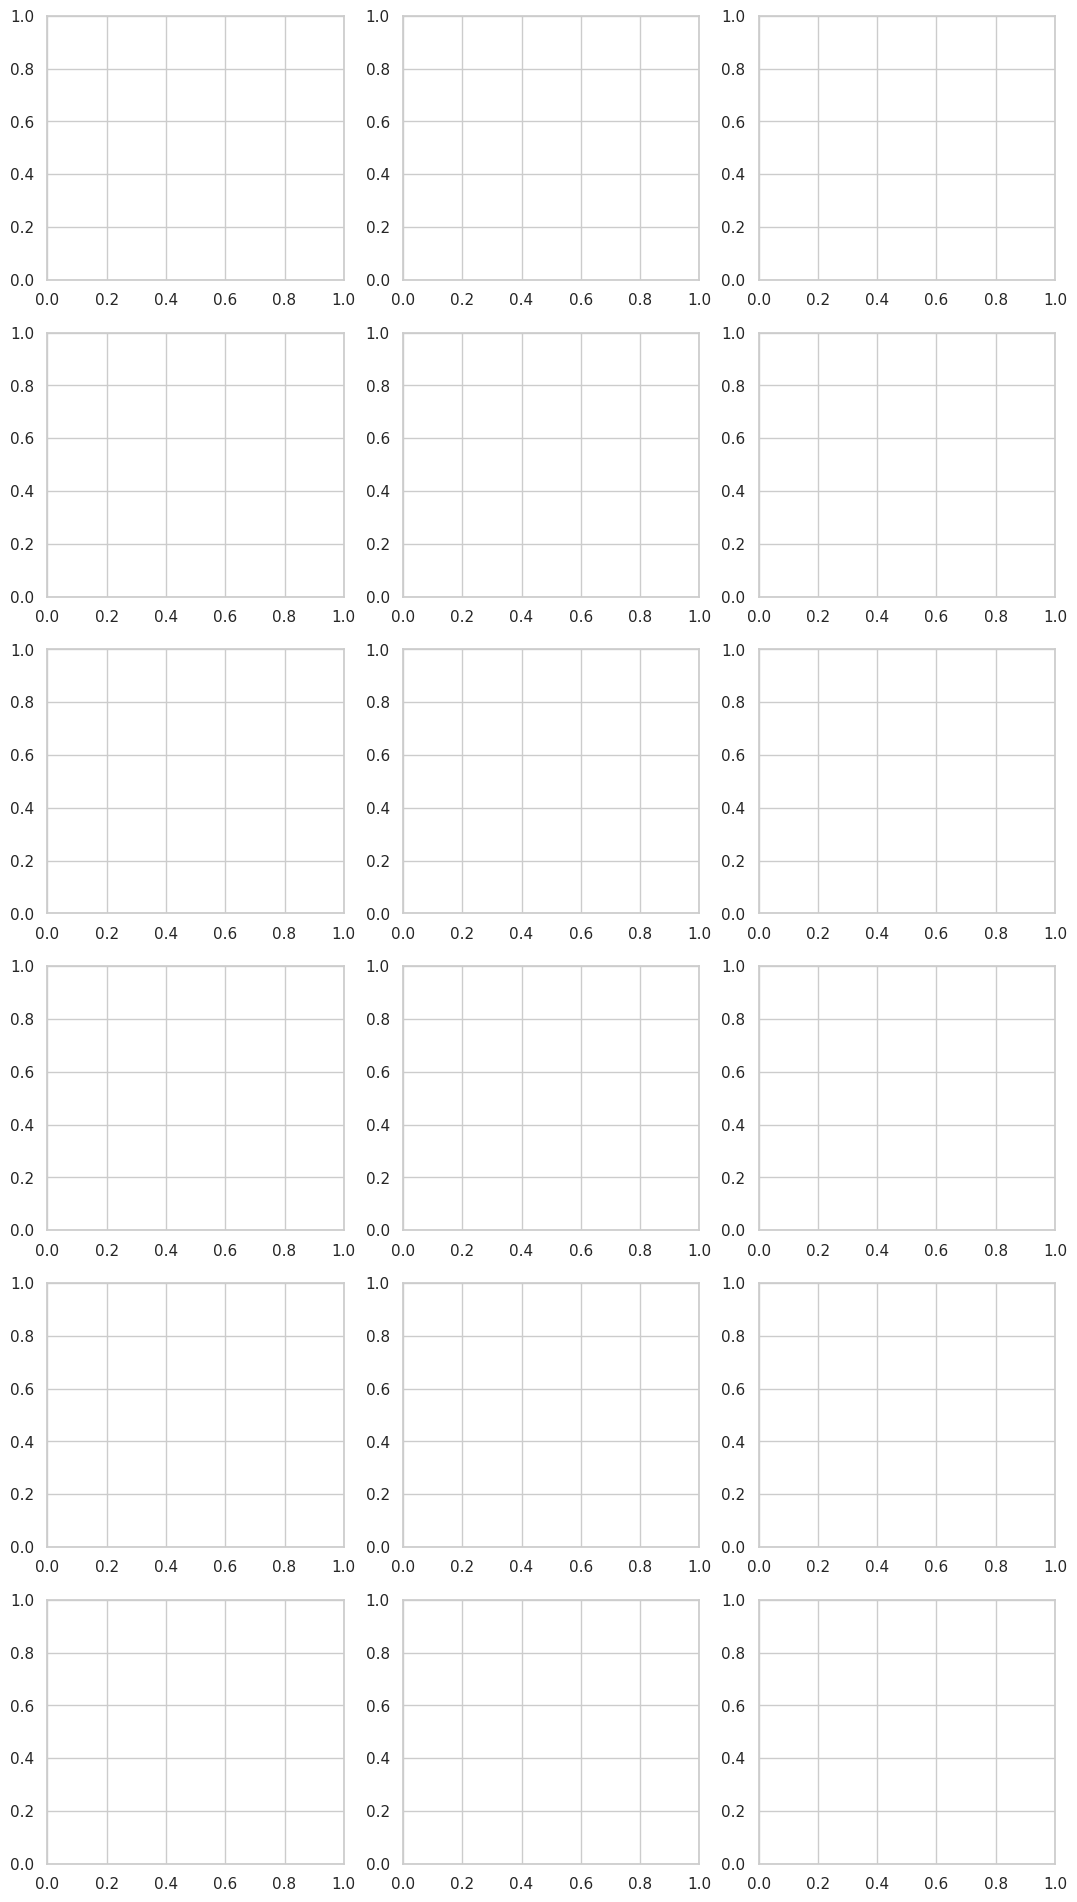

In [34]:
def prepare_single_image(path):
    image = load_rgb_image(path, target_size=IMG_SIZE)
    image_array = image.astype("float32") / 255.0
    return image, np.expand_dims(image_array, axis=0)

def predict_single(model, image_array):
    pred = model.predict(image_array, verbose=0)
    if num_classes == 2:
        score = float(pred.reshape(-1)[0])
        pred_label = int(score >= 0.5)
        probability = score if pred_label == 1 else 1 - score
    else:
        pred_label = int(np.argmax(pred[0]))
        probability = float(np.max(pred[0]))
    return pred_label, probability

def plot_gradcam_examples(df_candidates, title, max_examples=6):
    if len(df_candidates) == 0:
        print(f"Nenhum exemplo disponível para: {title}")
        return

    sample_df = df_candidates.head(max_examples)
    fig, axes = plt.subplots(len(sample_df), 3, figsize=(13, 4 * len(sample_df)))
    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, row) in enumerate(sample_df.iterrows()):
        original, image_array = prepare_single_image(row["path"])
        pred_label, probability = predict_single(best_image_model, image_array)
        heatmap = make_gradcam_heatmap(image_array, best_image_model, gradcam_feature_layer_name, class_index=pred_label)
        heatmap_resized, overlay = overlay_heatmap(original, heatmap)

        true_name = row["class_name"]
        pred_name = class_names[pred_label]

        axes[row_idx, 0].imshow(original)
        axes[row_idx, 0].set_title(f"Original\nReal: {true_name}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(heatmap_resized, cmap="jet")
        axes[row_idx, 1].set_title("Heatmap Grad-CAM")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title(f"Sobreposição\nPrevisto: {pred_name} ({probability:.2f})")
        axes[row_idx, 2].axis("off")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

test_predictions = []
for _, row in test_df.iterrows():
    _, image_array = prepare_single_image(row["path"])
    pred_label, probability = predict_single(best_image_model, image_array)
    test_predictions.append({**row.to_dict(), "pred_label": pred_label, "pred_class": class_names[pred_label], "probability": probability})

df_test_predictions = pd.DataFrame(test_predictions)
correct_examples = df_test_predictions[df_test_predictions["label"] == df_test_predictions["pred_label"]].sort_values("probability", ascending=False)
incorrect_examples = df_test_predictions[df_test_predictions["label"] != df_test_predictions["pred_label"]].sort_values("probability", ascending=False)

plot_gradcam_examples(correct_examples, "Grad-CAM em exemplos corretamente classificados")
plot_gradcam_examples(incorrect_examples, "Grad-CAM em exemplos classificados incorretamente")

## 11. YOLO para Detecção ou Segmentação - Verificação Condicional

YOLO exige anotações supervisionadas, como arquivos `.txt` no formato YOLO, bounding boxes, máscaras ou outro formato conversível. O notebook verifica a presença desses arquivos. Se não houver anotações adequadas, o treinamento YOLO não será executado, evitando fabricar labels ou sugerir segmentação inexistente.

In [35]:
def detect_yolo_labels(root_dir):
    txt_files = list(root_dir.rglob("*.txt"))
    yolo_like = []
    for txt_path in txt_files:
        try:
            lines = [line.strip() for line in txt_path.read_text(errors="ignore").splitlines() if line.strip()]
        except Exception:
            continue
        if not lines:
            continue
        valid_lines = 0
        for line in lines[:20]:
            parts = line.split()
            if len(parts) not in {5, 6}:
                continue
            try:
                values = [float(part) for part in parts]
                if values[0] >= 0 and all(0 <= value <= 1 for value in values[1:5]):
                    valid_lines += 1
            except ValueError:
                continue
        if valid_lines > 0:
            yolo_like.append(txt_path)
    return yolo_like

yolo_label_files = detect_yolo_labels(DATASET_DIR)
HAS_YOLO_LABELS = len(yolo_label_files) > 0

print(f"Arquivos compatíveis com labels YOLO encontrados: {len(yolo_label_files)}")
if HAS_YOLO_LABELS:
    print("Exemplos:")
    for path in yolo_label_files[:10]:
        print(path.relative_to(DATASET_DIR))
else:
    print("Não foram encontradas anotações YOLO suficientes para fine-tuning supervisionado.")

Arquivos compatíveis com labels YOLO encontrados: 0
Não foram encontradas anotações YOLO suficientes para fine-tuning supervisionado.


In [36]:
if HAS_YOLO_LABELS:
    try:
        from ultralytics import YOLO

        print(
            "Labels YOLO foram detectados. Ainda assim, é necessário confirmar se a estrutura possui "
            "imagens e labels separados em train/val/test e um data.yaml coerente."
        )
        yaml_files = list(DATASET_DIR.rglob("*.yaml")) + list(DATASET_DIR.rglob("*.yml"))
        if yaml_files:
            data_yaml = yaml_files[0]
            print("Arquivo YAML encontrado:", data_yaml)
            yolo_model = YOLO("yolov8n.pt")
            yolo_results = yolo_model.train(
                data=str(data_yaml),
                epochs=20,
                imgsz=224,
                project=str(YOLO_MODELS_DIR),
                name="brain_mri_yolo",
                seed=SEED,
            )
        else:
            print("Labels existem, mas não foi encontrado data.yaml. Organize o dataset no formato YOLO antes do treinamento.")
    except Exception as exc:
        print("YOLO não foi executado.")
        print(f"Motivo: {type(exc).__name__}: {exc}")
else:
    print(
        "YOLO não será treinado porque o dataset inspecionado não apresentou anotações supervisionadas "
        "compatíveis. Para detecção ou segmentação real, seriam necessárias bounding boxes ou máscaras "
        "anotadas por especialistas."
    )

YOLO não será treinado porque o dataset inspecionado não apresentou anotações supervisionadas compatíveis. Para detecção ou segmentação real, seriam necessárias bounding boxes ou máscaras anotadas por especialistas.


## 12. Discussão Opcional sobre GANs

GANs podem gerar imagens sintéticas e, em alguns cenários, apoiar aumento de dados. Em imagens médicas, porém, esse uso exige validação rigorosa, controle de qualidade e revisão especializada. Imagens sintéticas podem introduzir artefatos, reforçar vieses ou criar padrões irreais.

Neste projeto, GANs não são usadas como ferramenta principal porque o objetivo é classificação e interpretação visual, e não geração de imagens. Além disso, GANs não resolvem a ausência de máscaras ou bounding boxes para segmentação de tumores. Para localização anatômica validada, ainda seriam necessárias anotações feitas por especialistas.

## 13. Visualização Final de Resultados

A seção seguinte organiza exemplos visuais com classe real, classe prevista, probabilidade e Grad-CAM. Quando YOLO não é aplicável por falta de labels, a visualização interpretável permanece limitada aos mapas de ativação.

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133058603362848\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

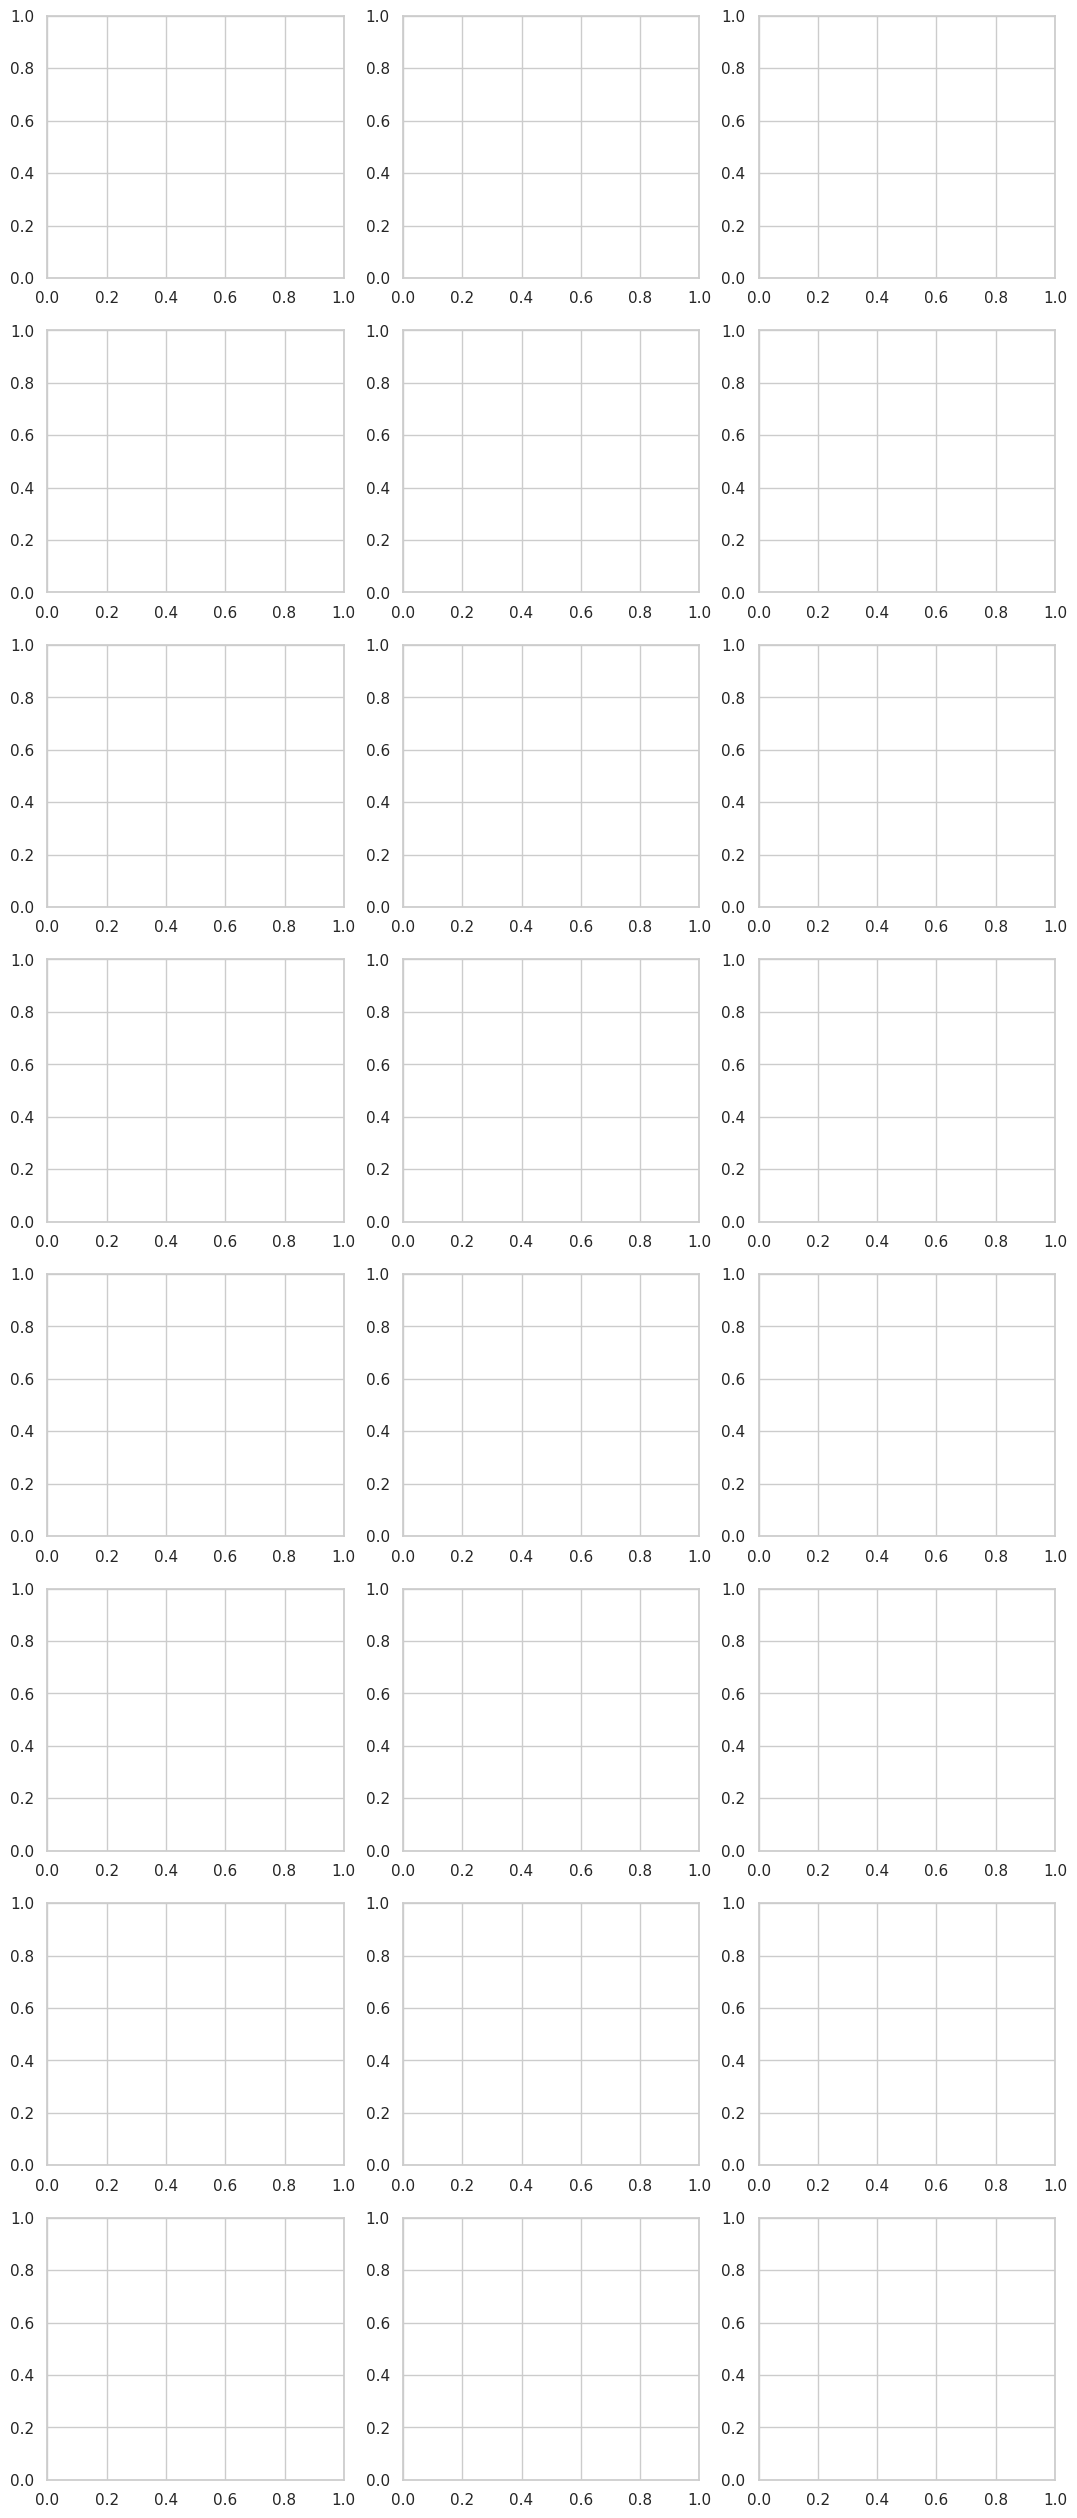

In [37]:
plot_gradcam_examples(df_test_predictions.sort_values("probability", ascending=False), "Exemplos finais com Grad-CAM", max_examples=8)

## 14. Salvamento dos Modelos

Os modelos treinados são salvos no formato `.keras`. O melhor classificador final também é salvo separadamente para facilitar uso posterior.

In [38]:
cnn_model.save(MODELS_DIR / "cnn_simples.keras")
transfer_model.save(MODELS_DIR / "transfer_learning_model.keras")
best_image_model.save(MODELS_DIR / "best_image_classifier.keras")

print("Modelos salvos:")
print(MODELS_DIR / "cnn_simples.keras")
print(MODELS_DIR / "transfer_learning_model.keras")
print(MODELS_DIR / "best_image_classifier.keras")

Modelos salvos:
/content/models/cnn_simples.keras
/content/models/transfer_learning_model.keras
/content/models/best_image_classifier.keras


In [39]:
modelo_carregado = keras.models.load_model(MODELS_DIR / "best_image_classifier.keras")
print("Melhor modelo carregado com sucesso:")
print(modelo_carregado.name)

Melhor modelo carregado com sucesso:
mobilenetv2_transfer_mri


## 15. Relatório Final e Discussão dos Resultados

O relatório abaixo é gerado após a execução do treinamento para evitar resultados inventados. Ele utiliza as métricas calculadas no próprio notebook e resume a análise de forma adequada para entrega acadêmica.

In [40]:
from IPython.display import Markdown

def format_metric(value):
    if pd.isna(value):
        return "não aplicável"
    return f"{value:.3f}"

best_row = ranking_models.iloc[0]
cnn_row = comparison_df[comparison_df["modelo"] == "CNN simples"].iloc[0]
transfer_row = comparison_df[comparison_df["modelo"] == "Transfer Learning MobileNetV2"].iloc[0]

has_yolo_text = (
    "Foram detectadas anotações compatíveis com YOLO, mas a execução depende da presença de um data.yaml coerente e da organização supervisionada das imagens e labels."
    if HAS_YOLO_LABELS
    else "Não foram encontradas anotações supervisionadas de bounding boxes ou máscaras no formato necessário para treinamento YOLO. Por isso, não foi realizado fine-tuning supervisionado de detecção ou segmentação, e a localização visual ficou restrita ao Grad-CAM."
)

relatorio = f'''
## Relatório Final e Discussão dos Resultados

Este notebook desenvolveu a etapa extra do Tech Challenge com Visão Computacional aplicada a imagens de ressonância magnética cerebral. O objetivo foi construir um fluxo experimental para classificação de imagens médicas, comparando uma CNN simples treinada do zero com um modelo baseado em Transfer Learning.

O dataset utilizado foi o **Brain Cancer MRI Dataset**, obtido diretamente do Kaggle. Antes da modelagem, a estrutura dos arquivos foi inspecionada para identificar classes, extensões, dimensões, canais, imagens inválidas e possíveis duplicatas. Essa verificação foi necessária para evitar assumir previamente a organização do conjunto de dados.

A análise exploratória avaliou o balanceamento entre classes, exemplos visuais, distribuição de largura e altura, modos de imagem, brilho e contraste. Esses elementos são importantes porque diferenças de aquisição, tamanho da base e desbalanceamento podem influenciar o desempenho dos modelos e aumentar o risco de overfitting.

As imagens foram redimensionadas para **224x224**, normalizadas para o intervalo `[0, 1]` e separadas em treino, validação e teste. Data augmentation foi aplicado apenas ao conjunto de treino, com o objetivo de aumentar a variabilidade visual durante o aprendizado sem contaminar validação ou teste.

A CNN simples obteve no teste: accuracy **{format_metric(cnn_row["accuracy"])}**, precision **{format_metric(cnn_row["precision"])}**, recall **{format_metric(cnn_row["recall"])}**, F1-score **{format_metric(cnn_row["f1"])}** e AUC **{format_metric(cnn_row["auc"])}**.

O modelo com Transfer Learning MobileNetV2 obteve no teste: accuracy **{format_metric(transfer_row["accuracy"])}**, precision **{format_metric(transfer_row["precision"])}**, recall **{format_metric(transfer_row["recall"])}**, F1-score **{format_metric(transfer_row["f1"])}** e AUC **{format_metric(transfer_row["auc"])}**.

Com base nos critérios de recall, F1-score, AUC e desempenho geral no teste, o melhor modelo selecionado foi **{best_image_model_name}**. Em aplicações médicas de triagem, recall é especialmente relevante, pois falsos negativos podem deixar de sinalizar imagens potencialmente suspeitas. Ainda assim, falsos positivos também precisam ser considerados, pois podem gerar ansiedade, exames adicionais e sobrecarga clínica.

A interpretação visual foi realizada com Grad-CAM, apresentando a imagem original, o mapa de ativação e a sobreposição do heatmap. O Grad-CAM indica regiões que influenciaram a decisão do modelo, mas não representa segmentação médica precisa. Para segmentação real de tumores, seriam necessárias máscaras anotadas por especialistas.

{has_yolo_text}

Como limitações, este estudo utiliza uma base pública específica, não realiza validação externa, não avalia vieses populacionais, não contempla revisão radiológica dos mapas de ativação e não possui validação prospectiva em ambiente clínico. Portanto, os resultados devem ser interpretados como prova de conceito acadêmica.

O modelo pode apoiar triagem inicial e priorização de análise, mas não substitui radiologistas, neurologistas, oncologistas ou outros profissionais de saúde. A decisão final sobre diagnóstico e conduta deve permanecer sempre com profissionais qualificados.

Como melhorias futuras, recomenda-se ampliar a base, validar com dados externos, calibrar probabilidades, avaliar outros modelos pré-treinados, coletar bounding boxes ou máscaras com especialistas e, somente com essas anotações, treinar modelos de detecção ou segmentação supervisionada.
'''

display(Markdown(relatorio))


## Relatório Final e Discussão dos Resultados

Este notebook desenvolveu a etapa extra do Tech Challenge com Visão Computacional aplicada a imagens de ressonância magnética cerebral. O objetivo foi construir um fluxo experimental para classificação de imagens médicas, comparando uma CNN simples treinada do zero com um modelo baseado em Transfer Learning.

O dataset utilizado foi o **Brain Cancer MRI Dataset**, obtido diretamente do Kaggle. Antes da modelagem, a estrutura dos arquivos foi inspecionada para identificar classes, extensões, dimensões, canais, imagens inválidas e possíveis duplicatas. Essa verificação foi necessária para evitar assumir previamente a organização do conjunto de dados.

A análise exploratória avaliou o balanceamento entre classes, exemplos visuais, distribuição de largura e altura, modos de imagem, brilho e contraste. Esses elementos são importantes porque diferenças de aquisição, tamanho da base e desbalanceamento podem influenciar o desempenho dos modelos e aumentar o risco de overfitting.

As imagens foram redimensionadas para **224x224**, normalizadas para o intervalo `[0, 1]` e separadas em treino, validação e teste. Data augmentation foi aplicado apenas ao conjunto de treino, com o objetivo de aumentar a variabilidade visual durante o aprendizado sem contaminar validação ou teste.

A CNN simples obteve no teste: accuracy **0.903**, precision **0.917**, recall **0.902**, F1-score **0.901** e AUC **0.992**.

O modelo com Transfer Learning MobileNetV2 obteve no teste: accuracy **0.960**, precision **0.962**, recall **0.960**, F1-score **0.960** e AUC **0.996**.

Com base nos critérios de recall, F1-score, AUC e desempenho geral no teste, o melhor modelo selecionado foi **Transfer Learning MobileNetV2**. Em aplicações médicas de triagem, recall é especialmente relevante, pois falsos negativos podem deixar de sinalizar imagens potencialmente suspeitas. Ainda assim, falsos positivos também precisam ser considerados, pois podem gerar ansiedade, exames adicionais e sobrecarga clínica.

A interpretação visual foi realizada com Grad-CAM, apresentando a imagem original, o mapa de ativação e a sobreposição do heatmap. O Grad-CAM indica regiões que influenciaram a decisão do modelo, mas não representa segmentação médica precisa. Para segmentação real de tumores, seriam necessárias máscaras anotadas por especialistas.

Não foram encontradas anotações supervisionadas de bounding boxes ou máscaras no formato necessário para treinamento YOLO. Por isso, não foi realizado fine-tuning supervisionado de detecção ou segmentação, e a localização visual ficou restrita ao Grad-CAM.

Como limitações, este estudo utiliza uma base pública específica, não realiza validação externa, não avalia vieses populacionais, não contempla revisão radiológica dos mapas de ativação e não possui validação prospectiva em ambiente clínico. Portanto, os resultados devem ser interpretados como prova de conceito acadêmica.

O modelo pode apoiar triagem inicial e priorização de análise, mas não substitui radiologistas, neurologistas, oncologistas ou outros profissionais de saúde. A decisão final sobre diagnóstico e conduta deve permanecer sempre com profissionais qualificados.

Como melhorias futuras, recomenda-se ampliar a base, validar com dados externos, calibrar probabilidades, avaliar outros modelos pré-treinados, coletar bounding boxes ou máscaras com especialistas e, somente com essas anotações, treinar modelos de detecção ou segmentação supervisionada.


In [42]:
import shutil
from pathlib import Path

# Caminho de destino no Google Drive
drive_target_dir = Path('/content/drive/MyDrive/PÓS TECH FIAP/IA PARA DEVS/Fase 1 - IA Foundations/Tech Challenger/TechCahllenge_Tireoide/extra')

# Criar as pastas no destino, se não existirem
drive_target_dir.mkdir(parents=True, exist_ok=True)

# Pastas do projeto que serão copiadas
pastas_para_copiar = ['data', 'models', 'reports']

for pasta in pastas_para_copiar:
    origem = PROJECT_ROOT / pasta
    destino = drive_target_dir / pasta

    if origem.exists():
        print(f"Copiando {origem.name} para {destino}...")
        shutil.copytree(origem, destino, dirs_exist_ok=True)
        print(f"{pasta} copiada com sucesso!")
    else:
        print(f"A pasta {origem} não foi encontrada.")

print("\nBackup para o Google Drive concluído!")

Copiando data para /content/drive/MyDrive/PÓS TECH FIAP/IA PARA DEVS/Fase 1 - IA Foundations/Tech Challenger/TechCahllenge_Tireoide/extra/data...
data copiada com sucesso!
Copiando models para /content/drive/MyDrive/PÓS TECH FIAP/IA PARA DEVS/Fase 1 - IA Foundations/Tech Challenger/TechCahllenge_Tireoide/extra/models...
models copiada com sucesso!
Copiando reports para /content/drive/MyDrive/PÓS TECH FIAP/IA PARA DEVS/Fase 1 - IA Foundations/Tech Challenger/TechCahllenge_Tireoide/extra/reports...
reports copiada com sucesso!

Backup para o Google Drive concluído!


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
